# Analise Exploratoria - Indicador Crianca Alfabetizada

Explora dados da Base dos Dados sobre o Indicador de Alfabetizacao por municipio, UF e Brasil.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega amostra local para exploracao inicial
df = pd.read_csv('../../data/samples/sample_indicador_municipio.csv')
df.head()

,id_municipio,nome_municipio,sigla_uf,ano,percentual_alfabetizados,meta_nacional
0,3550308,Sao Paulo,SP,2023,82.4,100.0
1,3304557,Rio de Janeiro,RJ,2023,78.1,100.0
2,3106200,Belo Horizonte,MG,2023,80.6,100.0
3,2927408,Salvador,BA,2023,71.3,100.0
4,4314902,Porto Alegre,RS,2023,85.2,100.0


In [2]:
print('Shape:', df.shape)
print('\nNulos:')
print(df.isnull().sum())
print('\nEstatisticas:')
df.describe()

Shape: (10, 6)

Nulos:
id_municipio                0
nome_municipio              0
sigla_uf                    0
ano                         0
percentual_alfabetizados    0
meta_nacional               0
dtype: int64

Estatisticas:


,id_municipio,ano,percentual_alfabetizados,meta_nacional
count,1.000000e+01,10.0,10.000000,10.0
mean,2.983898e+06,2023.0,74.720000,100.0
std,8.840589e+05,0.0,9.086351,0.0
min,1.501402e+06,2023.0,61.400000,100.0
25%,2.381202e+06,2023.0,68.825000,100.0
50%,3.016804e+06,2023.0,74.700000,100.0
75%,3.488870e+06,2023.0,81.950000,100.0
max,4.314902e+06,2023.0,86.700000,100.0


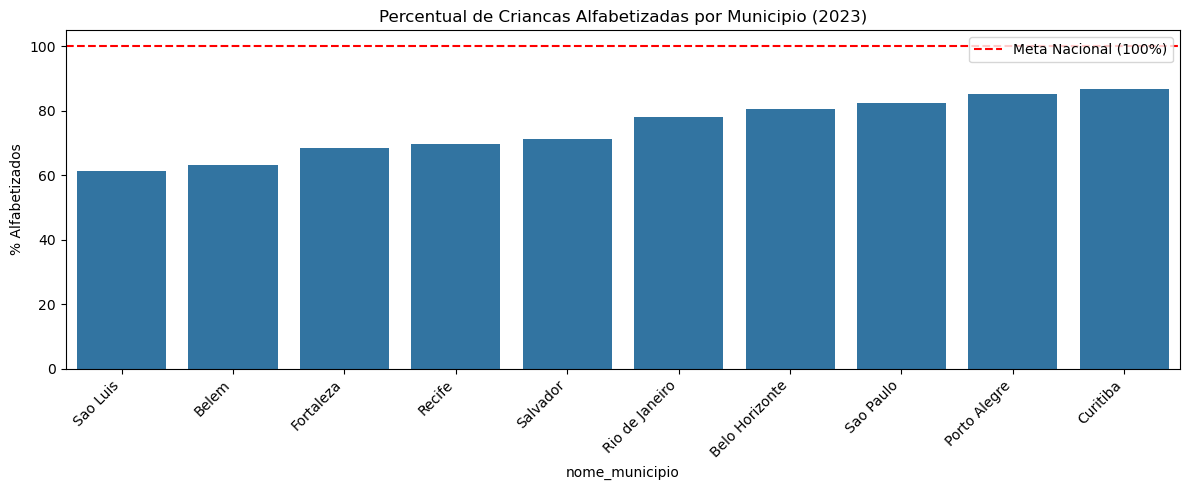

In [3]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df.sort_values('percentual_alfabetizados'), x='nome_municipio', y='percentual_alfabetizados')
plt.axhline(y=100, color='red', linestyle='--', label='Meta Nacional (100%)')
plt.xticks(rotation=45, ha='right')
plt.title('Percentual de Criancas Alfabetizadas por Municipio (2023)')
plt.ylabel('% Alfabetizados')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Gap em relacao a meta
df['gap_meta'] = df['percentual_alfabetizados'] - df['meta_nacional']
print('Top 5 municipios com maior gap (mais vulneraveis):')
df.nsmallest(5, 'percentual_alfabetizados')[['nome_municipio', 'sigla_uf', 'percentual_alfabetizados', 'gap_meta']]

Top 5 municipios com maior gap (mais vulneraveis):


,nome_municipio,sigla_uf,percentual_alfabetizados,gap_meta
9,Sao Luis,MA,61.4,-38.6
8,Belem,PA,63.2,-36.8
7,Fortaleza,CE,68.5,-31.5
6,Recife,PE,69.8,-30.2
3,Salvador,BA,71.3,-28.7
